## Calculating the critical threshold

In [1]:
import aliases # important this goes first to configure PATH

In [2]:
import os
import pickle
import math

import pandas as pd
from scipy.optimize import curve_fit
import numpy as np

from everest.window import Canvas, DataChannel as Channel

In [64]:
with open(
        os.path.join(
            aliases.storagedir, 'livestation', 'alphacrit_f_fine.pkl'
            ), mode='rb'
        ) as file:
    olddatas = pickle.load(file)

with open(
        os.path.join(
            aliases.storagedir, 'livestation', 'alphacrit_aspect_f.pkl'
            ), mode='rb'
        ) as file:
    alldatas = pickle.load(file)
newdatas = alldatas[1.0]

datas = {**olddatas, **newdatas}

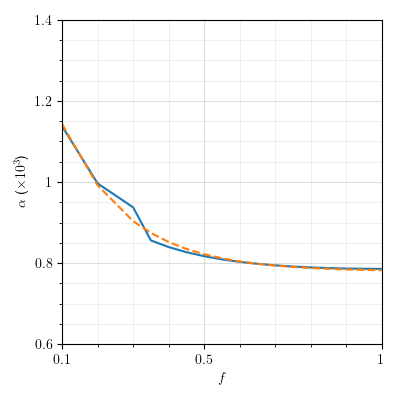

In [69]:
series = pd.Series({key: datas[key][-1] for key in sorted(datas)})

canvas = Canvas(size = (4, 4), shape = (1, 1))

ax = canvas.make_ax()
ax.line(
    xchan := Channel(
        series.index, label=r"$f$",
        capped=(True, True), log=False
        ),
    Channel(series.values, label=r"$\alpha$"),
    )

def func(x, /, a, b, c):
    return a * b**(x - c) + 8*math.pi**4
(*params,), error = curve_fit(func, series.index, series.values)
params = dict(zip('abcd', (map(float, params))))
model = func(series.index, **params)

ax.line(
    xchan,
    Channel(model),
    linestyle='--',
    )

canvas

In [68]:
params

{'a': 0.004830341288124885,
 'b': 0.004713834587047975,
 'c': 2.195899615944404,
 'd': 779.1618458439235}

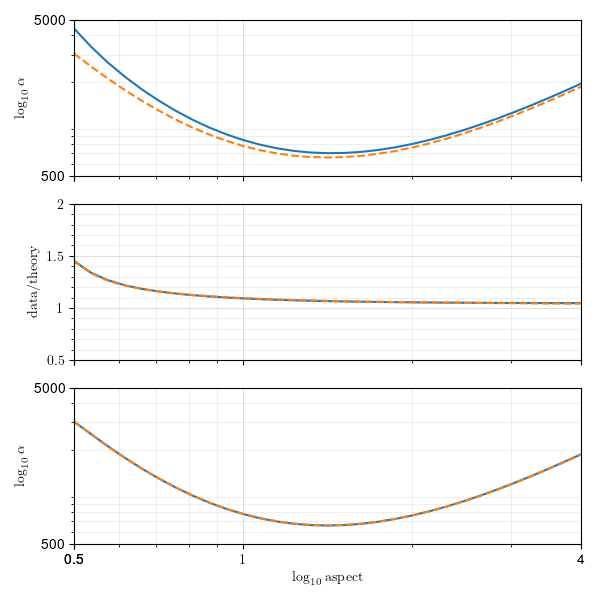

{'a': 0.0953389728853824,
 'b': 2.5102269596407503,
 'c': -0.4103586573941481,
 'd': 1.0305804697105057}

In [47]:
with open(
        os.path.join(
            aliases.storagedir, 'livestation', 'alphacrit_aspect_fine.pkl'
            ), mode='rb'
        ) as file:
    datas = pickle.load(file)

crit_func = lambda A: math.pi**4 * (1 + A**2)**3 / A**4
series = pd.Series({key: datas[key][-1] for key in sorted(datas)})
theory = tuple(map(crit_func, series.index))
ratios = series.values / theory

canvas = Canvas(size = (6, 6), shape = (3, 1))

ax1 = canvas.ax((0, 0))
ax1.line(
    xchan := Channel(
        series.index, label=r"$\mathrm{aspect}$",
        log=True, capped=(True, True),
        ),
    Channel(series.values, label=r"$\alpha$", log=True),
    )
ax1.line(
    xchan, Channel(theory, log=True),
    linestyle='--',
    )

ax1.props.edges.x.label.visible = False
ax1.props.edges.x.ticks.major.labels = ()
# ax1.props.edges.x.swap()
# ax1.props.edges.x.ticks.major.labels[:] = []

def func(x, /, a, b, c, d):
    return a / (b*(x + c)) + d
(*params,), error = curve_fit(func, series.index, ratios)
params = dict(zip('abcd', (map(float, params))))

correction = func(series.index, **params)

ax2 = canvas.ax((1, 0))
ax2.line(
    xchan,
    Channel(ratios, label=r'$\mathrm{data} / \mathrm{theory}$'),
    )
ax2.line(
    xchan,
    Channel(correction),
    linestyle='--',
    )

ax2.props.edges.x.label.visible = False
ax2.props.edges.x.ticks.major.labels = ()

ax3 = canvas.ax((2, 0))
ax3.line(
    xchan,
    Channel(series.values / correction, log=True),
    )
ax3.line(
    xchan,
    Channel(theory, label=r"$\alpha$", log=True),
    linestyle='--',
    )
display(canvas)
display(params)